In [1]:
import torch
import torch.nn as nn
import math
import time
import os
import numpy as np
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
baseline_model.eval()

print("Baseline GPT-2 loaded")

Baseline GPT-2 loaded


In [4]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

baseline_params = count_parameters(baseline_model)

print("Baseline parameters:", baseline_params)

Baseline parameters: 124439808


In [5]:
def kronecker_rank1(W, m1, m2, n1, n2):
    
    # reshape matrix
    W = W.reshape(m1, m2, n1, n2)
    
    # rearrange for SVD
    W = W.permute(0, 2, 1, 3).reshape(m1*n1, m2*n2)

    # SVD
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u * math.sqrt(s)).reshape(m1, n1)
    B = (v * math.sqrt(s)).reshape(m2, n2)

    return A.to(device), B.to(device)

In [7]:
def adaptive_normalization(W_original, W_kron):

    norm_original = torch.norm(W_original, p="fro")
    norm_kron = torch.norm(W_kron, p="fro")

    alpha = norm_original / norm_kron

    return alpha * W_kron

In [8]:
class KronLinear(nn.Module):

    def __init__(self, A, B, bias, out_dim):

        super().__init__()

        self.A = nn.Parameter(A)
        self.B = nn.Parameter(B)
        self.bias = nn.Parameter(bias.clone().to(device))

        self.out_dim = out_dim

        self.m1, self.n1 = A.shape
        self.m2, self.n2 = B.shape

    def forward(self, x):

        batch, seq, dim = x.shape

        x = x.reshape(batch*seq, self.n1, self.n2)

        x = torch.matmul(x, self.B.t())

        x = torch.matmul(self.A, x)

        x = x.reshape(batch, seq, self.out_dim)

        return x + self.bias

In [9]:
def compress_one_layer(model, layer_idx):

    block = model.transformer.h[layer_idx]

    # -------- c_fc --------

    W_fc = block.mlp.c_fc.weight.data.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A_fc, B_fc = kronecker_rank1(
        W_fc,
        m1=48, m2=64,
        n1=12, n2=64
    )

    W_kron_fc = torch.kron(A_fc, B_fc)

    W_kron_fc = adaptive_normalization(W_fc, W_kron_fc)

    block.mlp.c_fc = KronLinear(A_fc, B_fc, b_fc, out_dim=3072)


    # -------- c_proj --------

    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A_proj, B_proj = kronecker_rank1(
        W_proj,
        m1=12, m2=64,
        n1=48, n2=64
    )

    W_kron_proj = torch.kron(A_proj, B_proj)

    W_kron_proj = adaptive_normalization(W_proj, W_kron_proj)

    block.mlp.c_proj = KronLinear(A_proj, B_proj, b_proj, out_dim=768)

In [10]:
compressed_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
compressed_model.eval()

for i in range(12):
    compress_one_layer(compressed_model, i)

print("All layers compressed")

All layers compressed


In [11]:
dummy = tokenizer(
    "Artificial intelligence is amazing.",
    return_tensors="pt"
).to(device)

with torch.no_grad():
    out = compressed_model(**dummy)

print("Forward pass successful")
print("Logits shape:", out.logits.shape)

Forward pass successful
Logits shape: torch.Size([1, 6, 50257])


In [12]:
compressed_params = count_parameters(compressed_model)

print("Baseline parameters:", baseline_params)
print("Compressed parameters:", compressed_params)

Baseline parameters: 124439808
Compressed parameters: 67928832


In [13]:
torch.save(baseline_model.state_dict(), "baseline.pt")
torch.save(compressed_model.state_dict(), "compressed.pt")

baseline_size = os.path.getsize("baseline.pt")/1024**2
compressed_size = os.path.getsize("compressed.pt")/1024**2

print("Baseline size (MB):", baseline_size)
print("Compressed size (MB):", compressed_size)

Baseline size (MB): 474.753586769104
Compressed size (MB): 259.18871784210205


In [14]:
def measure_latency(model, runs=50):

    dummy = tokenizer(
        "Artificial intelligence is amazing.",
        return_tensors="pt"
    ).to(device)

    for _ in range(10):
        with torch.no_grad():
            model(**dummy)

    torch.cuda.synchronize()

    start = time.time()

    for _ in range(runs):
        with torch.no_grad():
            model(**dummy)

    torch.cuda.synchronize()

    end = time.time()

    return (end-start)/runs

In [15]:
baseline_latency = measure_latency(baseline_model)
compressed_latency = measure_latency(compressed_model)

print("Baseline latency ms:", baseline_latency*1000)
print("Compressed latency ms:", compressed_latency*1000)

Baseline latency ms: 9.617819786071777
Compressed latency ms: 11.437020301818848


In [16]:
def tokens_per_sec(model, runs=50):

    text = "Artificial intelligence is amazing."

    dummy = tokenizer(text, return_tensors="pt").to(device)

    tokens = dummy["input_ids"].shape[1]

    torch.cuda.synchronize()

    start = time.time()

    for _ in range(runs):
        with torch.no_grad():
            model(**dummy)

    torch.cuda.synchronize()

    end = time.time()

    return (tokens*runs)/(end-start)

In [17]:
baseline_tps = tokens_per_sec(baseline_model)
compressed_tps = tokens_per_sec(compressed_model)

print("Baseline TPS:", baseline_tps)
print("Compressed TPS:", compressed_tps)

Baseline TPS: 422.20725713014497
Compressed TPS: 424.56107912081535


In [18]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

eval_texts = dataset["validation"]["text"]

eval_texts = [t for t in eval_texts if len(t.strip())>0]

tokenized = tokenizer(
    eval_texts,
    truncation=True,
    padding="max_length",
    max_length=128
)

In [19]:
class WikiDataset(torch.utils.data.Dataset):

    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx])
        }


eval_dataset = WikiDataset(tokenized)

eval_loader = DataLoader(eval_dataset, batch_size=8)

In [20]:
def evaluate_perplexity(model, dataloader):

    model.eval()

    total_loss = 0
    total_tokens = 0

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask==0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            num_tokens = attention_mask.sum().item()

            total_loss += loss.item()*num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss/total_tokens

    return math.exp(avg_loss)

In [21]:
baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)

compressed_ppl = evaluate_perplexity(compressed_model, eval_loader)

print("Baseline PPL:", baseline_ppl)
print("Compressed PPL:", compressed_ppl)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Baseline PPL: 59.081966184984275
Compressed PPL: 50039.7159353178


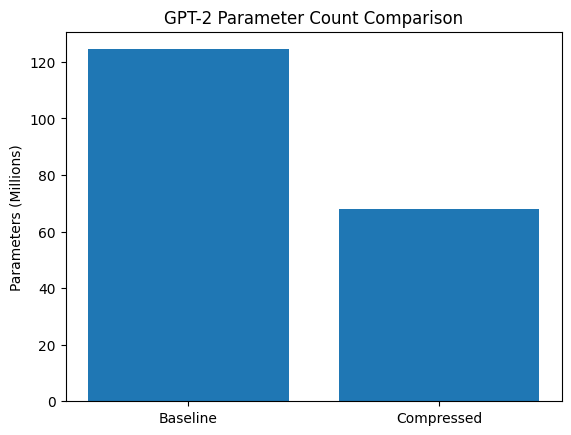

In [22]:
plt.figure()

plt.bar(
    ["Baseline", "Compressed"],
    [baseline_params/1e6, compressed_params/1e6]
)

plt.ylabel("Parameters (Millions)")
plt.title("GPT-2 Parameter Count Comparison")

plt.show()

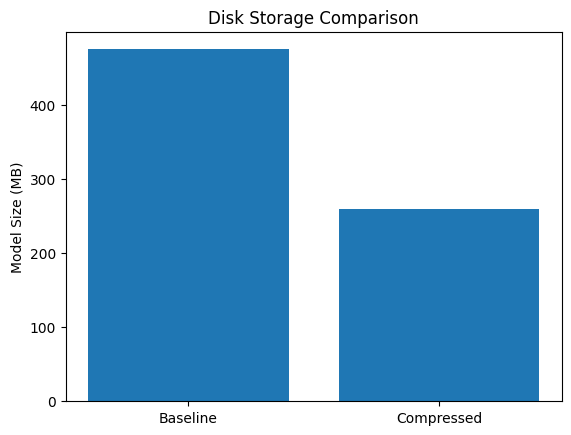

In [23]:
plt.figure()

plt.bar(
    ["Baseline", "Compressed"],
    [baseline_size, compressed_size]
)

plt.ylabel("Model Size (MB)")
plt.title("Disk Storage Comparison")

plt.show()

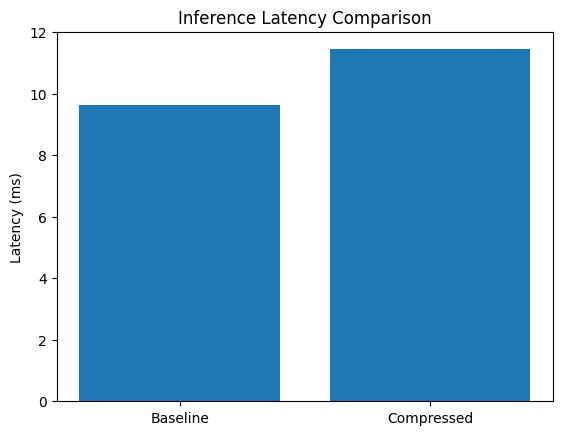

In [24]:
plt.figure()

plt.bar(
    ["Baseline", "Compressed"],
    [baseline_latency*1000, compressed_latency*1000]
)

plt.ylabel("Latency (ms)")
plt.title("Inference Latency Comparison")

plt.show()

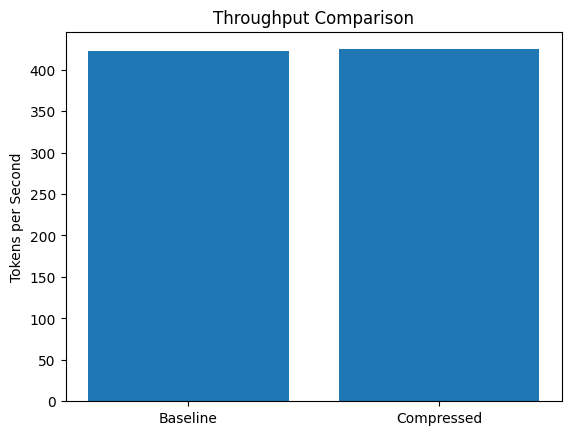

In [25]:
plt.figure()

plt.bar(
    ["Baseline", "Compressed"],
    [baseline_tps, compressed_tps]
)

plt.ylabel("Tokens per Second")
plt.title("Throughput Comparison")

plt.show()

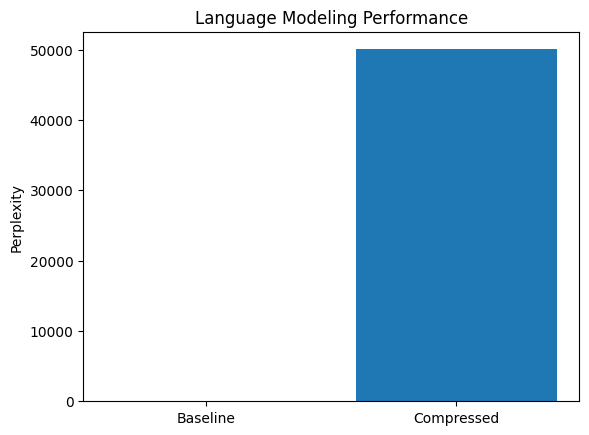

In [26]:
plt.figure()

plt.bar(
    ["Baseline", "Compressed"],
    [baseline_ppl, compressed_ppl]
)

plt.ylabel("Perplexity")
plt.title("Language Modeling Performance")

plt.show()

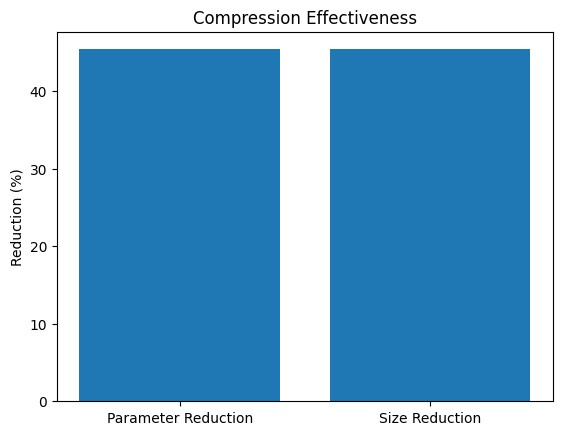

In [27]:
param_reduction = (baseline_params - compressed_params) / baseline_params * 100
size_reduction = (baseline_size - compressed_size) / baseline_size * 100

plt.figure()

plt.bar(
    ["Parameter Reduction", "Size Reduction"],
    [param_reduction, size_reduction]
)

plt.ylabel("Reduction (%)")
plt.title("Compression Effectiveness")

plt.show()

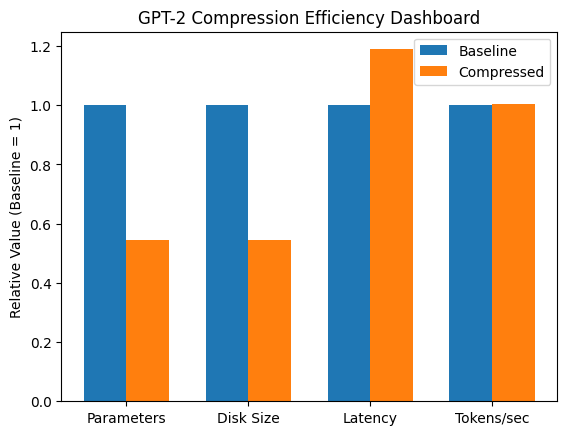

In [28]:
metrics = ["Parameters", "Disk Size", "Latency", "Tokens/sec"]

baseline_values = [1, 1, 1, 1]

compressed_values = [
    compressed_params/baseline_params,
    compressed_size/baseline_size,
    compressed_latency/baseline_latency,
    compressed_tps/baseline_tps
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, baseline_values, width, label="Baseline")
ax.bar(x + width/2, compressed_values, width, label="Compressed")

ax.set_ylabel("Relative Value (Baseline = 1)")
ax.set_title("GPT-2 Compression Efficiency Dashboard")

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.legend()

plt.show()

In [29]:
compression_ratio = baseline_params / compressed_params

print("Compression Ratio:", compression_ratio)


Compression Ratio: 1.8319144365679658
